In [11]:
import sys, os
import labview_sequence.labview as lv
from local_paths import local_path
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp


# Locate the sequence file next to labview.py (works regardless of notebook cwd)
seq_file = local_path('lvseqread', 2024, 9, 4, 423)
seq = lv.seq_read(seq_file)
print(f"Loaded: version={seq.version}, timing={seq.timing} ms")


Loaded: version=4, timing=100 ms


In [12]:
# Bitter coil channels are identified by their LabVIEW OG prefix (none contain the word "bitter")
bitter_search_terms = ['3.0_', '3.3_', '3.5_', '3.6_', '3.7_', 'COIL', '6.31', '6.21', 'IServo']

seen = set()
bitter_channels = []
for term in bitter_search_terms:
    for ch_no in lv.get_channels_by_name(seq, term):
        if ch_no not in seen:
            bitter_channels.append(ch_no)
            seen.add(ch_no)

print(f"Found {len(bitter_channels)} Bitter coil channels:\n")
print(f"  {'ch':>4}  {'LV name':<30}  {'ival':>8}  analog")
print(f"  {'--':>4}  {'-------':<30}  {'----':>8}  ------")
for ch_no in bitter_channels:
    ch = lv.get_channel_by_no(seq, ch_no)
    print(f"  {ch_no:>4}  {ch['name']:<30}  {ch['ival']:>8.4f}  {bool(ch['is_analog'])}")


Found 14 Bitter coil channels:

    ch  LV name                             ival  analog
    --  -------                             ----  ------
     0  3.0_N_V_AH                        0.1883  True
     3  3.3_lower_FF                      0.0000  True
     5  3.5_AH_upper_FF                   0.0000  True
     6  3.6_HH_upper_FF                   0.0000  True
     7  3.7_N_V_HH                       -0.0183  True
   104  5.18_COIL_BOT_CC                  1.0000  True
   105  5.19_COIL_TOP_CV                  2.0000  True
   106  5.20_COIL_TOP_CC                  1.0000  True
   107  5.21_COIL_BOT_CV                  1.5000  True
   109  5.23_COIL_TOP_AH                  5.0000  True
   110  5.24_COIL_TOP_HH                  0.0000  True
    85  6.31_B_Precision_Disable          5.0000  False
    75  6.21_FF_Disable                   0.0000  False
   113  5.27_IServo_FB_Switch             0.0000  True


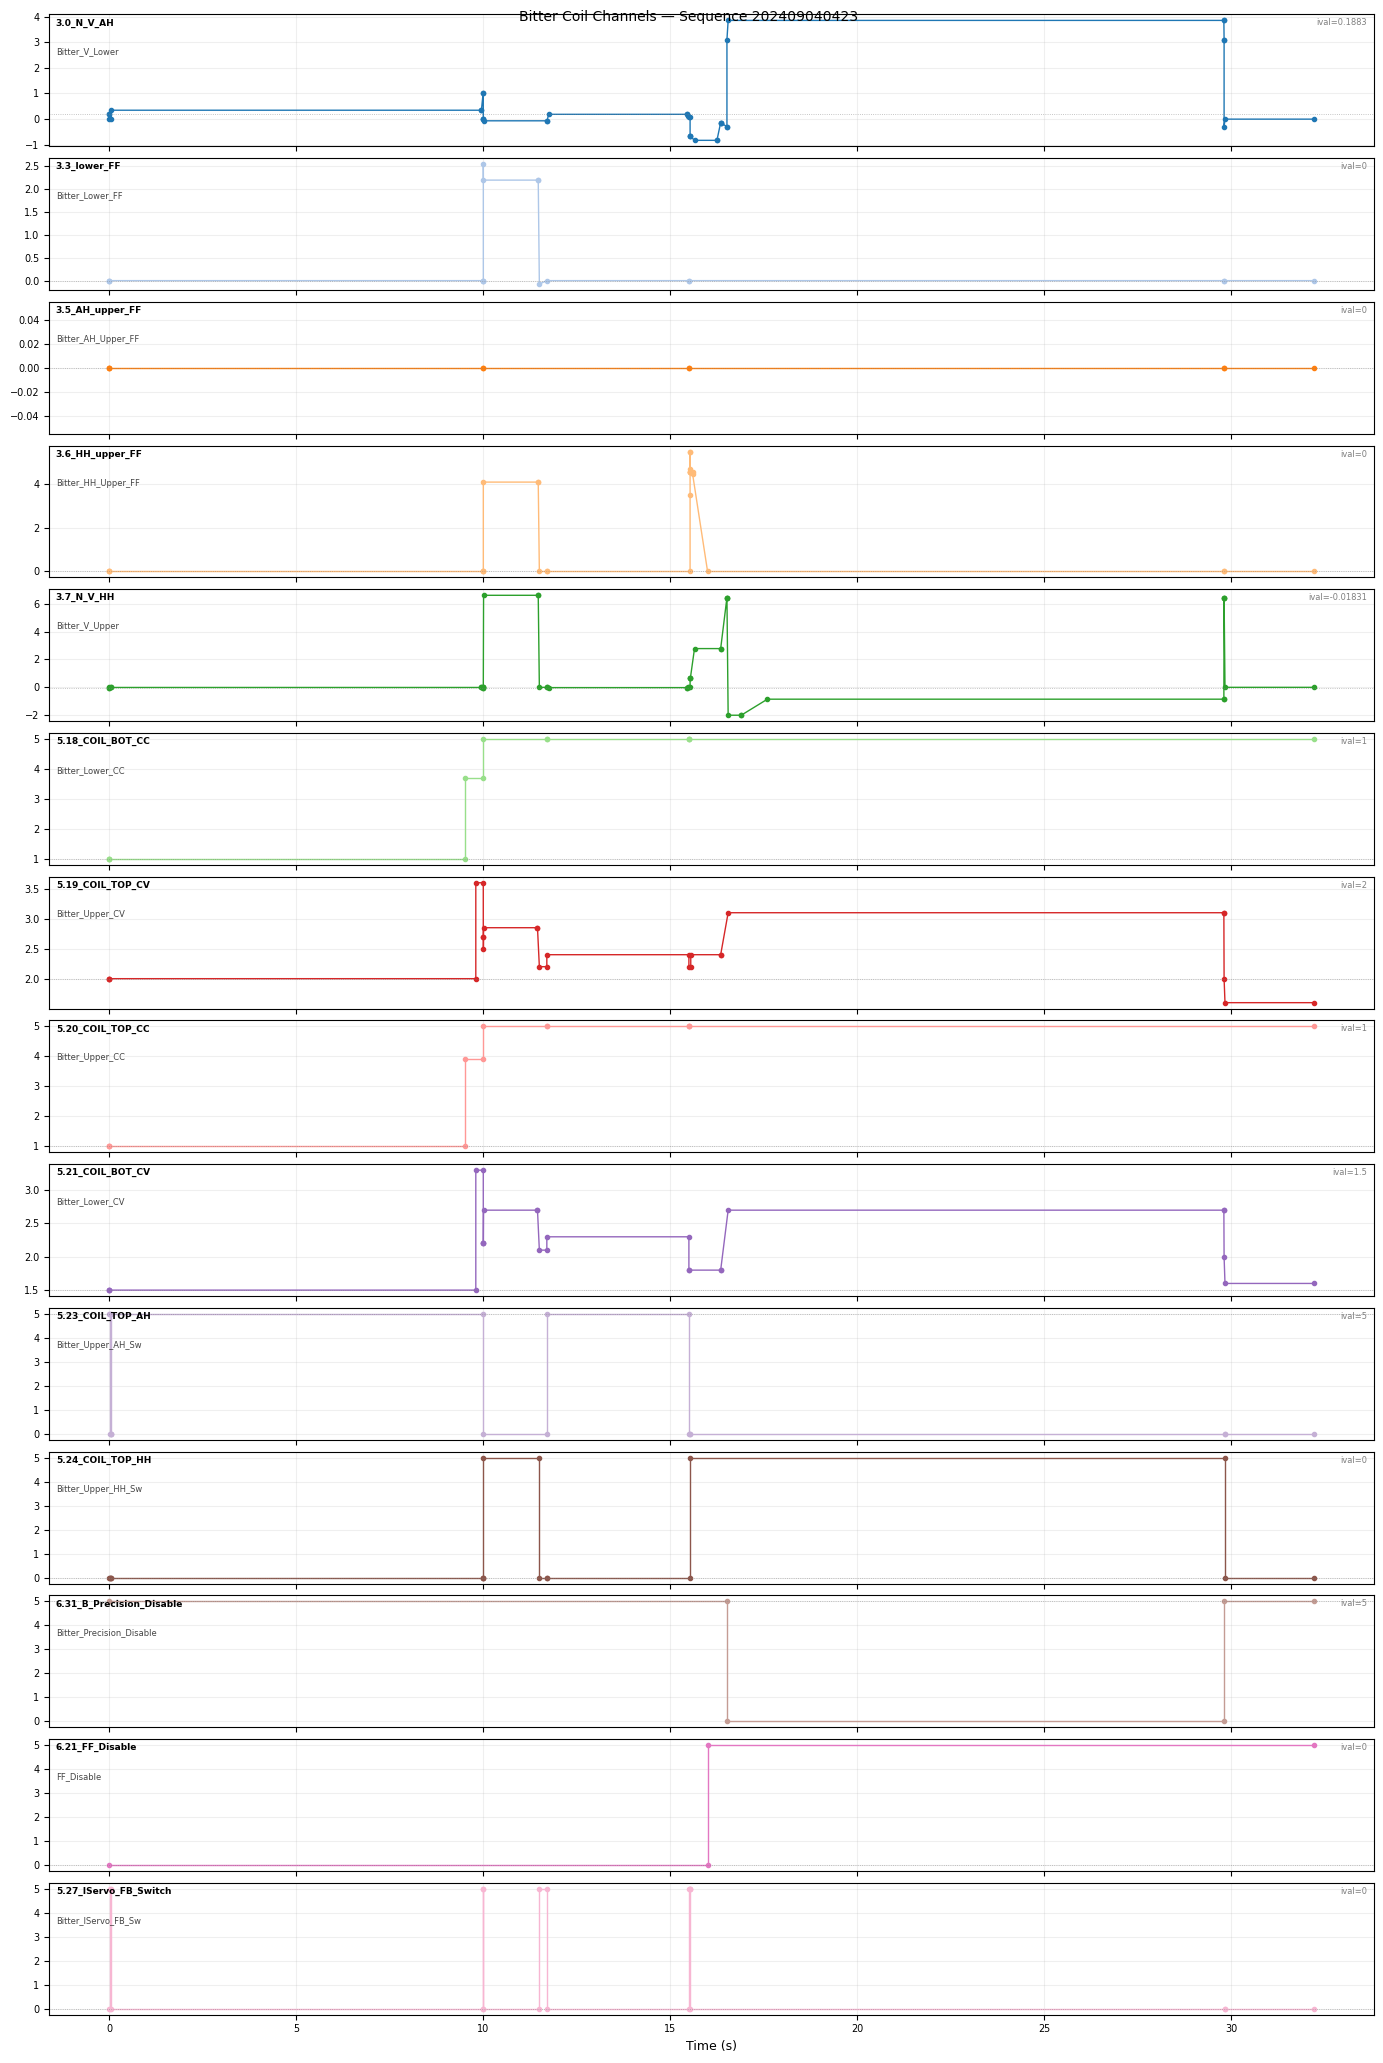

In [ ]:
import csv

def build_channel_waveform(seq, ch_no, t_end_ms=None):
    """Returns (times_s, voltages) for channel ch_no as a step/ramp waveform.

    JUMP events (ramp_res=0) produce a vertical step; FINE/COARSE ramps (ramp_res=1,2)
    produce a linear segment from the preceding event to the ramp endpoint, matching
    how labview_labscript_convert reconstructs the waveform.
    """
    ch = lv.get_channel_by_no(seq, ch_no)
    ival = lv.var_lookup(seq.ramp_params, ch['ival'])

    events = []
    num_procs = seq.proc_details['dims'][0]
    num_ev    = seq.proc_details['dims'][1]

    for p in range(num_procs):
        if not seq.procedures['enabled'][p]:
            continue
        proc_t = lv.var_lookup(seq.ramp_params, seq.procedures['time'][p])
        for e in range(num_ev):
            if not seq.proc_details['enabled'][p, e]:
                continue
            if int(seq.proc_details['channel_no'][p, e]) != ch_no:
                continue
            ev_t  = lv.var_lookup(seq.ramp_params, seq.proc_details['time'][p, e])
            ev_v  = lv.var_lookup(seq.ramp_params, seq.proc_details['voltage'][p, e])
            ev_rr = int(seq.proc_details['ramp_res'][p, e])
            events.append((proc_t + ev_t, ev_v, ev_rr))

    events.sort(key=lambda x: x[0])

    t_pts, v_pts = [0.0], [ival]
    prev_t, prev_v = 0.0, ival

    for t, v, rr in events:
        if rr == 0:  # JUMP: hold current value then step
            if t > prev_t:
                t_pts.append(t)
                v_pts.append(prev_v)
            t_pts.append(t)
            v_pts.append(v)
        else:  # FINE/COARSE: linear ramp from the previous event to this endpoint
            t_pts.append(t)
            v_pts.append(v)
        prev_t, prev_v = t, v

    if t_end_ms is not None and t_pts[-1] < t_end_ms:
        t_pts.append(t_end_ms)
        v_pts.append(prev_v)

    return np.array(t_pts) / 1e3, np.array(v_pts)  # ms → s


# ── Build OG prefix → labscript name map from NI_channel_map.csv ─────────────
csv_path = os.path.join(os.path.dirname(lv.__file__), 'NI_channel_map.csv')
og_to_labscript = {}
with open(csv_path, newline='') as f:
    for row in csv.DictReader(f):
        og = row['OG Ch'].strip()
        new_name = row['New Name'].strip()
        if og and new_name:
            og_to_labscript[og] = new_name


# ── Find sequence end time (ms) ───────────────────────────────────────────────
t_end_ms = 0.0
for p in range(seq.proc_details['dims'][0]):
    if not seq.procedures['enabled'][p]:
        continue
    proc_t = lv.var_lookup(seq.ramp_params, seq.procedures['time'][p])
    for e in range(seq.proc_details['dims'][1]):
        if seq.proc_details['enabled'][p, e]:
            ev_t = lv.var_lookup(seq.ramp_params, seq.proc_details['time'][p, e])
            t_end_ms = max(t_end_ms, proc_t + ev_t)
t_end_ms += 10  # 10 ms tail pad


# ── Plot ──────────────────────────────────────────────────────────────────────
n = len(bitter_channels)
fig, axes = plt.subplots(n, 1, figsize=(14, n * 1.5), sharex=True)
if n == 1:
    axes = [axes]

colors = plt.cm.tab20.colors

for i, (ax, ch_no) in enumerate(zip(axes, bitter_channels)):
    ch = lv.get_channel_by_no(seq, ch_no)
    t_s, v = build_channel_waveform(seq, ch_no, t_end_ms)

    ax.plot(t_s, v, '.-', color=colors[i % 20], linewidth=1.0)
    ax.axhline(ch['ival'], color='gray', lw=0.6, ls=':', alpha=0.6)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

    lv_name = ch['name']
    og_prefix = lv_name.split('_', 1)[0]
    ls_name = og_to_labscript.get(og_prefix, '')

    ax.text(0.005, 0.97, lv_name, transform=ax.transAxes,
            fontsize=6.5, va='top', fontweight='bold')
    if ls_name:
        ax.text(0.005, 0.97 - 0.22, ls_name, transform=ax.transAxes,
                fontsize=6, va='top', color='#444444')
    ax.text(0.995, 0.97, f"ival={ch['ival']:.4g}", transform=ax.transAxes,
            fontsize=6, va='top', ha='right', color='gray')

axes[-1].set_xlabel('Time (s)', fontsize=9)
fig.suptitle('Bitter Coil Channels — Sequence 202409040423', fontsize=10)
fig.tight_layout(h_pad=0.5)
plt.savefig('bitter_sequence_full.pdf')
plt.show()



In [ ]:
# ── Find procedures that modify Bitter channels ──────────────────────────────
# Depends on: bitter_channels, seq, lv, build_channel_waveform, t_end_ms,
#             og_to_labscript, colors  (all defined in earlier cells)

bitter_set = set(bitter_channels)
active_procs = []

for p in range(seq.proc_details['dims'][0]):
    if not seq.procedures['enabled'][p]:
        continue
    proc_t = lv.var_lookup(seq.ramp_params, seq.procedures['time'][p])

    ev_times = []
    for e in range(seq.proc_details['dims'][1]):
        if not seq.proc_details['enabled'][p, e]:
            continue
        if int(seq.proc_details['channel_no'][p, e]) not in bitter_set:
            continue
        ev_t = lv.var_lookup(seq.ramp_params, seq.proc_details['time'][p, e])
        ev_times.append(proc_t + ev_t)

    if not ev_times:
        continue

    t_min, t_max = min(ev_times), max(ev_times)
    pad = max((t_max - t_min) * 0.15, 5)  # at least 5 ms on each side
    active_procs.append({
        'idx': p,
        'name': seq.procedures['name'][p],
        't_lo': (t_min - pad) / 1e3,   # seconds
        't_hi': (t_max + pad) / 1e3,
    })

print(f"{len(active_procs)} procedures modify Bitter channels:")
for proc in active_procs:
    print(f"  {proc['idx']:03d}: {proc['name']}")


# ── One figure per procedure ─────────────────────────────────────────────────
for proc in active_procs:
    n = len(bitter_channels)
    fig, axes = plt.subplots(n, 1, figsize=(12, n * 1.4), sharex=True)
    if n == 1:
        axes = [axes]

    for i, (ax, ch_no) in enumerate(zip(axes, bitter_channels)):
        ch = lv.get_channel_by_no(seq, ch_no)
        t_s, v = build_channel_waveform(seq, ch_no, t_end_ms)

        ax.plot(t_s, v, color=colors[i % 20], linewidth=1.2)
        ax.axhline(ch['ival'], color='gray', lw=0.6, ls=':', alpha=0.5)
        ax.set_xlim(proc['t_lo'], proc['t_hi'])
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2)

        lv_name = ch['name']
        ls_name = og_to_labscript.get(lv_name.split('_', 1)[0], '')
        ax.text(0.005, 0.97, lv_name, transform=ax.transAxes,
                fontsize=6.5, va='top', fontweight='bold')
        if ls_name:
            ax.text(0.005, 0.70, ls_name, transform=ax.transAxes,
                    fontsize=6, va='top', color='#555')
        ax.text(0.995, 0.97, f"ival={ch['ival']:.4g}", transform=ax.transAxes,
                fontsize=6, va='top', ha='right', color='gray')

    axes[-1].set_xlabel('Time (s)', fontsize=9)
    fig.suptitle(f"Proc {proc['idx']:03d}: {proc['name']}", fontsize=10)
    fig.tight_layout(h_pad=0.1)
    plt.show()


/var/folders/r1/3pwt_y8x3m39pdps_fxcbw480000gn/T/ipykernel_79110/4274613611.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


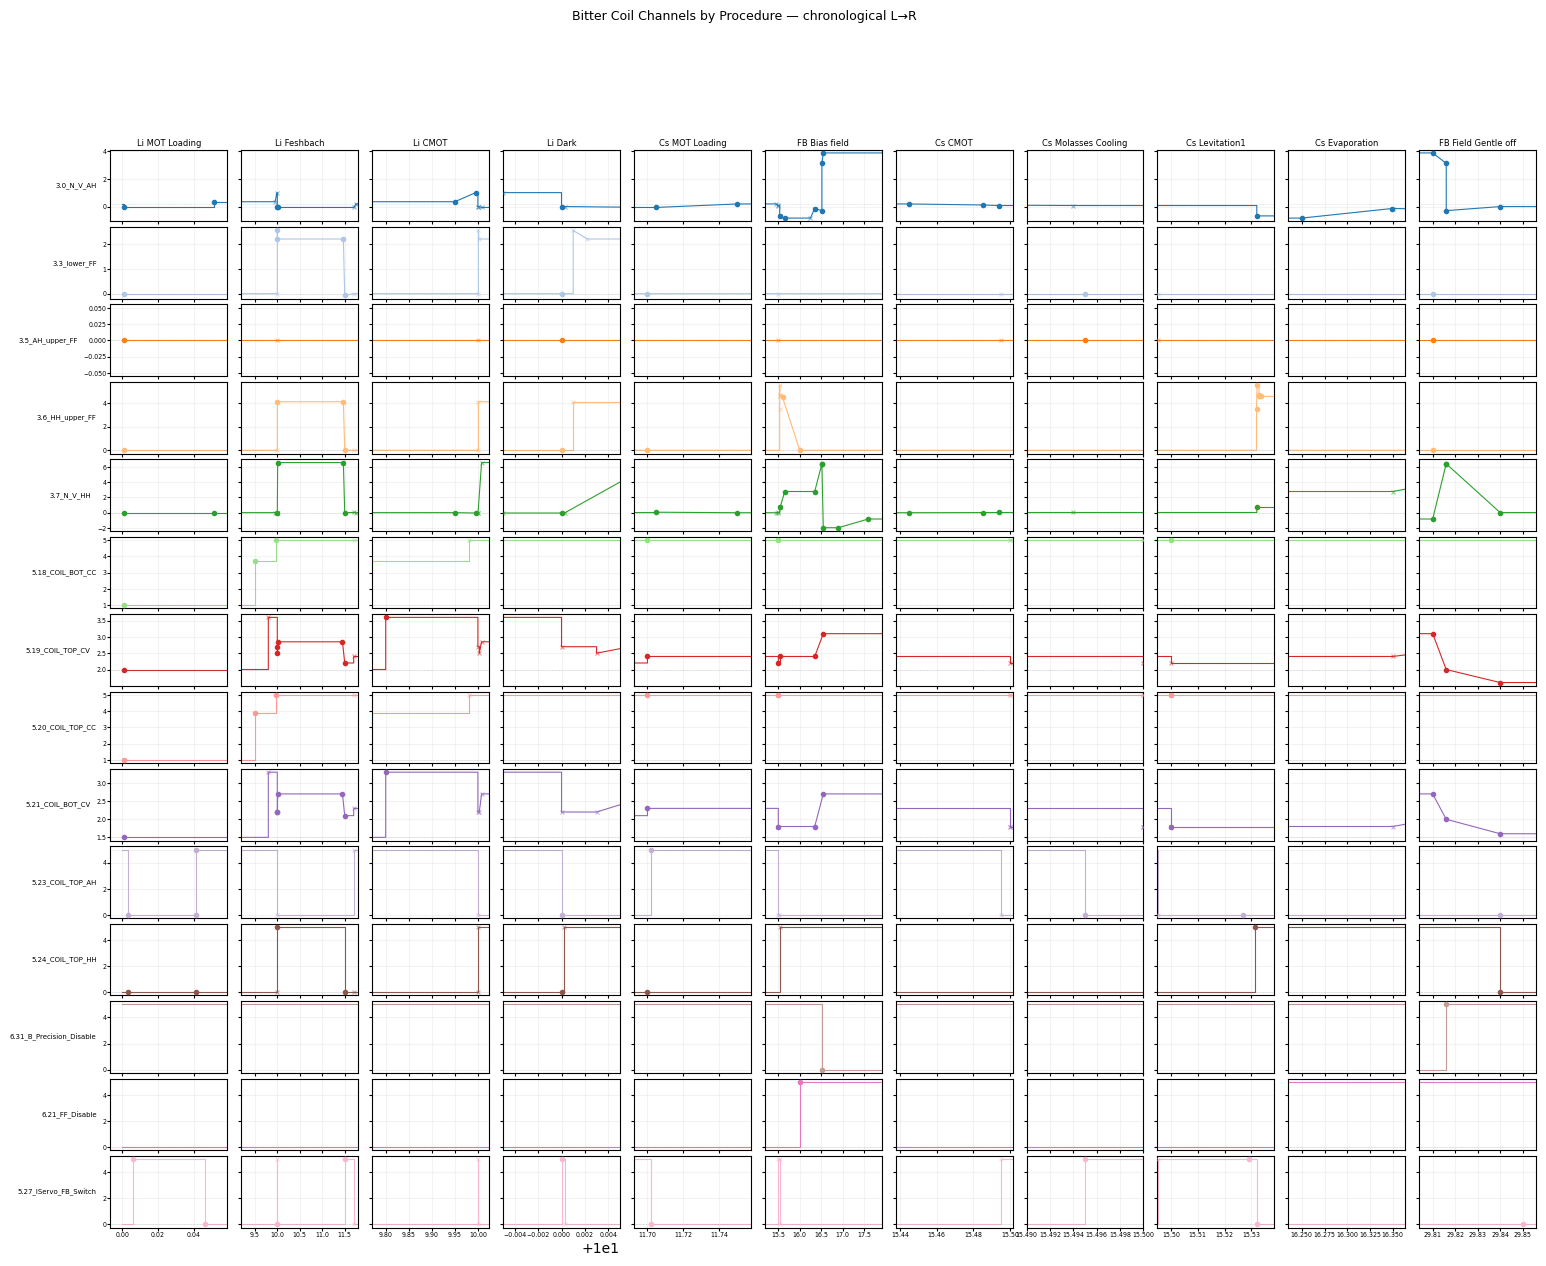

In [24]:
import matplotlib.gridspec as gridspec


def get_events_by_proc(seq, ch_no):
    """Returns {proc_idx: [(abs_time_s, voltage), ...]} for channel ch_no."""
    result = {}
    num_procs = seq.proc_details['dims'][0]
    num_ev    = seq.proc_details['dims'][1]
    for p in range(num_procs):
        if not seq.procedures['enabled'][p]:
            continue
        proc_t = lv.var_lookup(seq.ramp_params, seq.procedures['time'][p])
        for e in range(num_ev):
            if not seq.proc_details['enabled'][p, e]:
                continue
            if int(seq.proc_details['channel_no'][p, e]) != ch_no:
                continue
            ev_t = lv.var_lookup(seq.ramp_params, seq.proc_details['time'][p, e])
            ev_v = lv.var_lookup(seq.ramp_params, seq.proc_details['voltage'][p, e])
            result.setdefault(p, []).append(((proc_t + ev_t) / 1e3, ev_v))
    return result


# Sort procedures chronologically by their earliest Bitter event
active_procs_chron = sorted(active_procs, key=lambda p: p['t_lo'])

n_ch   = len(bitter_channels)
n_proc = len(active_procs_chron)

# Pre-compute per-channel event lookup (avoids scanning proc_details 154 times)
ev_cache = {ch_no: get_events_by_proc(seq, ch_no) for ch_no in bitter_channels}

fig = plt.figure(figsize=(n_proc * 1.8, n_ch * 1.0))
gs  = gridspec.GridSpec(n_ch, n_proc, hspace=0.08, wspace=0.12)

row_axes = [[] for _ in range(n_ch)]

for i, ch_no in enumerate(bitter_channels):
    ev_by_proc = ev_cache[ch_no]

    for j, proc in enumerate(active_procs_chron):
        sharey = row_axes[i][0] if j > 0 else None
        ax = fig.add_subplot(gs[i, j], sharey=sharey)
        row_axes[i].append(ax)

        ch = lv.get_channel_by_no(seq, ch_no)
        t_s, v = build_channel_waveform(seq, ch_no, t_end_ms)

        # Line only — markers handled separately below
        ax.plot(t_s, v, '-', color=colors[i % 20], linewidth=0.8)
        ax.axhline(ch['ival'], color='gray', lw=0.4, ls=':', alpha=0.5)
        ax.set_xlim(proc['t_lo'], proc['t_hi'])
        ax.tick_params(labelsize=4.5, length=2, pad=1)
        ax.grid(True, alpha=0.15)

        # Circles for events belonging to this procedure
        own = ev_by_proc.get(proc['idx'], [])
        if own:
            t_o, v_o = zip(*own)
            ax.plot(t_o, v_o, 'o', color=colors[i % 20], ms=3, zorder=5)

        # X markers for events from other procedures visible in this window
        for p_idx, evs in ev_by_proc.items():
            if p_idx == proc['idx']:
                continue
            visible = [(t, v) for t, v in evs if proc['t_lo'] <= t <= proc['t_hi']]
            if visible:
                t_x, v_x = zip(*visible)
                ax.plot(t_x, v_x, 'x', color=colors[i % 20],
                        ms=3, mew=0.8, alpha=0.5, zorder=4)

        # Suppress interior tick labels
        if i < n_ch - 1:
            ax.tick_params(labelbottom=False)
        if j > 0:
            ax.tick_params(labelleft=False)

        # Channel names as y-labels on leftmost column
        if j == 0:
            lv_name = ch['name']
            ax.set_ylabel(lv_name, fontsize=5, rotation=0, ha='right', va='center')

        # Procedure names as column headers on top row
        if i == 0:
            ax.set_title(proc['name'].replace('_', ' '), fontsize=6, pad=3)

fig.suptitle('Bitter Coil Channels by Procedure — chronological L→R', fontsize=9)
fig.tight_layout()
plt.subplots_adjust(left=0.18)
plt.savefig('bitter_subsequences.pdf')
plt.show()
